In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from re import X
from scipy import stats
import random
import time
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Main Functions

## Generate objective

In [ ]:
def generate_objective(a_mat, labels):
    n = a_mat.shape[0]
    labels = np.asarray(labels, dtype=int).ravel()

    def probs_from_Z(Z):
        Z_stable = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_stable)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def loss_from_Z(Z):
        Z_stable = Z - np.max(Z, axis=1, keepdims=True)
        log_sum_exp = np.log(np.sum(np.exp(Z_stable), axis=1))
        correct_scores = Z_stable[np.arange(n), labels]
        return -np.mean(correct_scores - log_sum_exp)

    def jacobian_from_Z(Z):
        P = probs_from_Z(Z)
        P[np.arange(n), labels] -= 1
        return (a_mat.T @ P) / n

    return loss_from_Z, jacobian_from_Z, probs_from_Z

In [ ]:
def softmax_logits(Z):
  Z_stable = Z - np.max(Z, axis=1, keepdims=True)
  exp_Z = np.exp(Z_stable)
  return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

## Armijo

In [ ]:
"""
ARMIJO RULE
"""
def armijo(loss_function, x, a, gradient, fx, delta=0.5, gamma=1e-4, alpha=0.1):

    grad_norm_sq = np.dot(gradient.ravel(), gradient.ravel())

    while True:
        x_new = x - alpha * gradient
        ax = a @ x_new
        new_fx = loss_function(ax)

        if new_fx <= fx - gamma * alpha * grad_norm_sq:
            break

        alpha *= delta

    return alpha

## Get accuracy

In [ ]:
def accuracy_bcgd(probs, y_test):
  y_hat = np.argmax(probs, axis=1)
  # flattening y_test
  y_test = y_test.ravel()
  return(accuracy_score(y_test, y_hat))

In [ ]:
def get_accuracy(logits, y_test):
  # softmax
  logits = logits - np.max(logits, axis=1, keepdims=True)
  probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
  # predictions
  y_hat = np.argmax(probs, axis=1)
  y_test = y_test.ravel()
  return(accuracy_score(y_test, y_hat))

# GRADIENT DESCENT

In [ ]:
"""
STANDARD GRADIENT DESCENT
"""
def gradient_descent(loss_function, jacobian, a, y, num_iter=5000, x0 = None,
                          tol = 1e-4, stepsize_strat = None, stepsize = 0.1, max_time = 900):
  x = x0.copy()
  n=len(x)

  acc_l = []
  time_l = []
  if stepsize_strat == "armijo":
    alpha = stepsize
  elif stepsize_strat == 'L':
    L = (np.linalg.norm(a, 2) ** 2) / (2 * a.shape[0])
    alpha = 1 / L
    print(f'Lipschitz stepsize: {alpha}')

  #starting time
  start_time = time.time()
  Z = a @ x
  fx = loss_function(Z)
  f_history = [fx]
  acc_l.append(get_accuracy(Z, y))
  grad = jacobian(Z)
  time_l.append(time.time() - start_time)

  for iter in range(num_iter):
    running_time = time.time() - start_time

    if running_time >= max_time:
      print(f"Stopped because max_time={max_time} seconds was reached.")
      break

    #Armijo rule
    if stepsize_strat == "armijo":
      alpha = armijo(loss_function = loss_function, x = x, a = a, gradient = grad, fx = fx, alpha = alpha)

    #update the weights
    x_new = x - alpha * grad
    Z = a @ x_new
    fx_new = loss_function(Z)
    grad = jacobian(Z)
    time_l.append(time.time() - start_time)
    acc_l.append(get_accuracy(Z, y))
    f_history.append(fx_new)
    fx = fx_new
    x = x_new

    #check stop condition
    if (iter > 0 and np.linalg.norm(grad) < tol) or acc_l[-1] == 1.0:
      print(f'The running time of the gradient descent with tolerance as stop is {time.time() - start_time}')
      break
    if time.time() - start_time > max_time:
      break
  print(f'The running time of the gradient descent with time as stop is {time.time() - start_time}')
  print(iter)

  results = {
             'X' : x,
             'Time' : time_l,
             'Accuracy History' : acc_l,
             'Loss History' : f_history,
             'Number Iteration' : iter+1
             }

  return results

# RANDOMIZED BCGD

## Randomized armijo

In [ ]:
"""
BCGD ARMIJO
"""
def random_armijo(loss_logits, x, labels, a_col, Z, fx, direction, index,
                  delta = 0.5, gamma = 1e-4, Delta_k = 1):
  """
  We need a loss_function that takes in input only the logit matrix, without computing it from scratch each time
  start_k = Delta_k; a good starting value is stepsize_k-1
  direction is the gradient of the block
  """
  alpha = Delta_k #alpha is the starting  point
  #fx = loss_function(x) #this can called outside the funciton to decrease the number of calls (with the print )
  grad_norm =  np.linalg.norm(direction) # gradient norm
  while True:
    Z_updating = Z - alpha * np.outer(a_col, direction)

    if loss_logits(Z_updating) <= fx - gamma * alpha * (grad_norm**2):
      break #we find a good alpha that gurantees a sufficient decrease compared to the linear approximation

    alpha *=  delta #this is the stepsize that's updated through the iterations

    if alpha <= 1e-20: # if alpha is too small the cycle stops
      break

  return alpha

## Randomized function

In [ ]:
def randomized_bcgd(loss_logits,
                    a_matrix,
                    probs_from_Z,
                    labels,
                    x_matrix,
                    armijo_flag=False, max_iter=20000, max_time=600, tol=1e-4):

  x_copy = x_matrix.copy()
  n, d = a_matrix.shape

  Z = a_matrix @ x_copy #logits

  loss_history = []
  gradient_history = []
  acc_history = []
  alpha_history = []

  start_time = time.time()
  time_history = []

  block_L = 0.5 * np.sum(a_matrix ** 2, axis=0) / n # with axis = 0 i am taking the column of a, which is the row of X
  valid_blocks = block_L > 1e-12 #mark the index of blocks where the Lipshitx cinstant is not 0

  if not armijo_flag:
    alpha = np.zeros_like(block_L)
    alpha[valid_blocks] = 1.0 / block_L[valid_blocks] # compute alpha vector, which contains stepsize for each block

  for t in range(max_iter):

    running_time = time.time() - start_time

    if (t > 0 and running_time >= max_time) or (t > 0 and acc_history[-1] == 1.0):
      print(f"Stopped because max_time={max_time} seconds was reached.")
      break

    j = np.random.randint(d) #I can draw the same value one multiple times in a row (di fila)

    P = probs_from_Z(Z)
    acc_history.append(accuracy_bcgd(probs=P, y_test=labels))

    Q = P.copy() #operate on the copy of P
    Q[np.arange(n), labels] -= 1 #subtract 1 only from the true class
    #instead of create a matrix of one-hot encoding, we do this directly using numpy

    grad_j = a_matrix[:, j] @ Q / n #gradient of the bock
    grad_norm_j = np.linalg.norm(grad_j) #norm of the block gradient

    fx = loss_logits(Z)
    loss_history.append(fx)
    gradient_history.append(grad_norm_j)

    #store the time at each iteration
    time_history.append(running_time)

    ##STOP CONDITION
    #the stopping condition is only based on time, and it is checked at the beginning of each iteration

    if not armijo_flag:  # armijo == False
      if not valid_blocks[j]: #if the stepsize in this case is -infinite --> index not valid so we skip this iteration
        continue

      alpha_j = alpha[j] #stepsize

    else:
      # armijo == True
      if not valid_blocks[j]:
        continue

      alpha_j = random_armijo(
          loss_logits=loss_logits,
          x=x_copy,
          labels=labels,
          a_col=a_matrix[:, j],
          Z=Z,
          fx=fx,
          direction=grad_j,
          index=j,
          Delta_k=1.0
      )

    alpha_history.append(alpha_j)

    # Update
    delta_j = alpha_j * grad_j
    x_copy[j, :] -= delta_j

    # here i have also to update the probability matrix,
    # since it changes because x changes, so i update the logits
    # controllare notion, P = softamx(A @ X) = softmax(Z)
    Z -= np.outer(a_matrix[:, j], delta_j)
    #P = softmax_logits(Z) redundant

  results = {
        "X": x_copy,
        "Time": np.array(time_history),
        "Accuracy History": np.array(acc_history),
        "Loss History": np.array(loss_history),
        "Gradient History": np.array(gradient_history),
        "Number Iteration": t + 1,
        "Alpha History": alpha_history
        }

  return results

# GAUSS-SOUTHWELL BCGD

In [ ]:
def bcgd_GS(loss_logits, a_matrix, labels, x_matrix, armijo_flag=False, max_iter=10000, max_time=600, tol=1e-4):
  #max_time is in seconds
  #compute the stepsize, which is known for the softmax loss
  x_copy = x_matrix.copy()
  n, d = a_matrix.shape

  Z = a_matrix @ x_copy #logits

  loss_history = []
  gradient_history = []
  acc_history = []
  alpha_history = []

  start = time.time()
  time_history = []

  #compute the fixed stepsize from the Lipschitx constant
  block_L = 0.5 * np.sum(a_matrix ** 2, axis=0) / n # with axis = 0 i am taking the column of a, which is the row of X
  valid_blocks = block_L > 1e-12

  if not armijo_flag:
    alpha = np.zeros_like(block_L)
    alpha[valid_blocks] = 1.0 / block_L[valid_blocks] # compute alpha vector, which contains stepsize for each block

  for t in range(max_iter):

    running_time = time.time() - start

    if (t > 0 and running_time >= max_time) or (t > 0 and acc_history[-1] == 1.0):
      print(f"Stopped because max_time={max_time} seconds was reached.")
      break

    P = softmax_logits(Z) #matrix of probabilities

    #compute the accuracy:
    acc_history.append(accuracy_bcgd(probs=P, y_test=labels))

    Q = P.copy()
    Q[np.arange(n), labels] -= 1

    grad = a_matrix.T @ Q / n #instead of using jacobian function, we use this more direct computation
    norm_grad = np.linalg.norm(grad, axis=1)

    #extract the feature with the largest gradient; heap structure is useless
    #because I have to recompute the matrix probability from scratch
    idx = np.argmax(norm_grad)

    #print values of the loss and the gradient each 100 iterations
    fx = loss_logits(Z)
    loss_history.append(fx)
    gradient_history.append((idx, norm_grad[idx]))
    #print(norm_grad[idx])

    #store the time of each iteration
    time_history.append(running_time)

    ##STOP CONDITION
    #the stopping condition is only based on time, and it is checked at the beginning of each iteration

    ##STEPSIZE SEARCH
    if not armijo_flag:
      if not valid_blocks[idx]:
        continue

      alpha_idx = alpha[idx]

    else: #armijo_flag==True
      if not valid_blocks[idx]:
        continue

      alpha_idx = random_armijo(
          loss_logits=loss_logits,
          x=x_copy,
          labels=labels,
          a_col=a_matrix[:, idx],
          Z=Z,
          fx=fx,
          direction=grad[idx, :],
          index=idx,
          Delta_k=1.0
      )

    alpha_history.append(alpha_idx)

    #update the weights using stepsize
    delta_idx = alpha_idx * grad[idx, :]
    x_copy[idx, :] -= delta_idx
    #else: #armijo, to implement

    Z -= np.outer(a_matrix[:, idx], delta_idx) #updates of the logits

  #print(f'Running time: {running_time}; Number of iterations: {t}')
  results = {
             'X': x_copy,
             'Time': time_history,
             'Accuracy History': acc_history,
             'Loss History': loss_history,
             'Gradient History': gradient_history,
             'Alpha History': alpha_history,
             'Number Iteration': t + 1
             }

  return results

# SYNTHETIC DATA

In [ ]:
a = np.random.randn(1000,1000)
print(a.shape)
true_x = np.random.randn(1000,50)
print(true_x.shape)

e = np.random.randn(1000,50)
print(e.shape)

out = a @ true_x + e
print(out.shape)
ground_truth= []

p_mat = softmax_logits(out)
ground_truth = np.argmax(p_mat, axis=1)

print(len(ground_truth))
print(type(ground_truth))
print(ground_truth[:3])
x_start = np.random.randn(1000,50) # matrix of the weights

(1000, 1000)
(1000, 50)
(1000, 50)
(1000, 50)
1000
<class 'numpy.ndarray'>
[48 18 27]


## Execution of synthetic data

In [ ]:
d = a.shape[1]
k = int(np.max(ground_truth)) + 1
x_start = np.random.randn(d, k)
#x_start = np.zeros((d, k)) all weights start at 0
MAX_TIME = 600


loss_function, jacobian, probs_from_Z = generate_objective(a, ground_truth)

synthetic_gd_fixed = gradient_descent(loss_function, jacobian, a = a, y = ground_truth,
                                                      x0 = x_start, stepsize_strat = 'L')
synthetic_gd_armijo = gradient_descent(loss_function, jacobian, a = a, y = ground_truth,
                                                      x0 = x_start, stepsize_strat = 'armijo')


Lipschitz stepsize: 0.5062231622465776
The running time of the gradient descent with tolerance as stop is 5.583019018173218
The running time of the gradient descent with time as stop is 5.583125591278076
247
The running time of the gradient descent with tolerance as stop is 38.17918586730957
The running time of the gradient descent with time as stop is 38.17929458618164
1253


In [ ]:
synthetic_rbcgd_fixed = randomized_bcgd(
    loss_logits=loss_function,
    a_matrix=a,
    probs_from_Z=probs_from_Z,
    labels=ground_truth,
    x_matrix=x_start,
    armijo_flag=False,
    max_iter=1000000,
    max_time=MAX_TIME
)

synthetic_rbcgd_armijo = randomized_bcgd(
    loss_logits=loss_function,
    a_matrix=a,
    probs_from_Z=probs_from_Z,
    labels=ground_truth,
    x_matrix=x_start,
    armijo_flag=True,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.
Stopped because max_time=600 seconds was reached.


In [ ]:
synthetic_gs_fixed = bcgd_GS(
    loss_logits=loss_function,
    a_matrix=a,
    labels=ground_truth,
    x_matrix=x_start,
    armijo_flag=False,
    max_iter=1000000,
    max_time=MAX_TIME
)

synthetic_gs_armijo = bcgd_GS(
    loss_logits=loss_function,
    a_matrix=a,
    labels=ground_truth,
    x_matrix=x_start,
    armijo_flag=True,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.
Stopped because max_time=600 seconds was reached.


## SYNTETIC DATA PLOTS

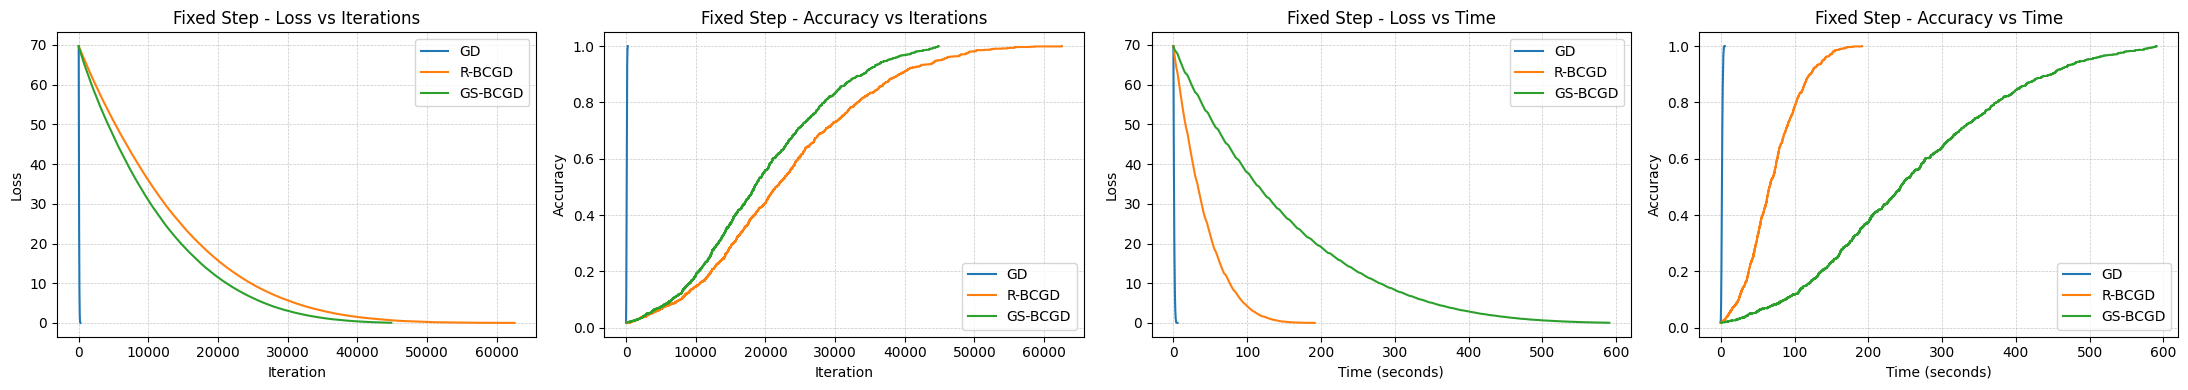

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 4))
ax1, ax2, ax3, ax4 = axes
for ax in axes:
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax1.plot(synthetic_gd_fixed["Loss History"], label="GD")
ax1.plot(synthetic_rbcgd_fixed["Loss History"], label="R-BCGD")
ax1.plot(synthetic_gs_fixed["Loss History"], label="GS-BCGD")
ax1.set_title("Fixed Step - Loss vs Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(synthetic_gd_fixed["Accuracy History"], label="GD")
ax2.plot(synthetic_rbcgd_fixed["Accuracy History"], label="R-BCGD")
ax2.plot(synthetic_gs_fixed["Accuracy History"], label="GS-BCGD")
ax2.set_title("Fixed Step - Accuracy vs Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Accuracy")
ax2.legend()

ax3.plot(synthetic_gd_fixed["Time"], synthetic_gd_fixed["Loss History"], label="GD")
ax3.plot(synthetic_rbcgd_fixed["Time"], synthetic_rbcgd_fixed["Loss History"], label="R-BCGD")
ax3.plot(synthetic_gs_fixed["Time"], synthetic_gs_fixed["Loss History"], label="GS-BCGD")
ax3.set_title("Fixed Step - Loss vs Time")
ax3.set_xlabel("Time (seconds)")
ax3.set_ylabel("Loss")
ax3.legend()

ax4.plot(synthetic_gd_fixed["Time"], synthetic_gd_fixed["Accuracy History"], label="GD")
ax4.plot(synthetic_rbcgd_fixed["Time"], synthetic_rbcgd_fixed["Accuracy History"], label="R-BCGD")
ax4.plot(synthetic_gs_fixed["Time"], synthetic_gs_fixed["Accuracy History"], label="GS-BCGD")
ax4.set_title("Fixed Step - Accuracy vs Time")
ax4.set_xlabel("Time (seconds)")
ax4.set_ylabel("Accuracy")
ax4.legend()

plt.tight_layout()
plt.show()

In [ ]:
synthetic_rbcgd_fixed['Time'][-1]

np.float64(191.55077385902405)

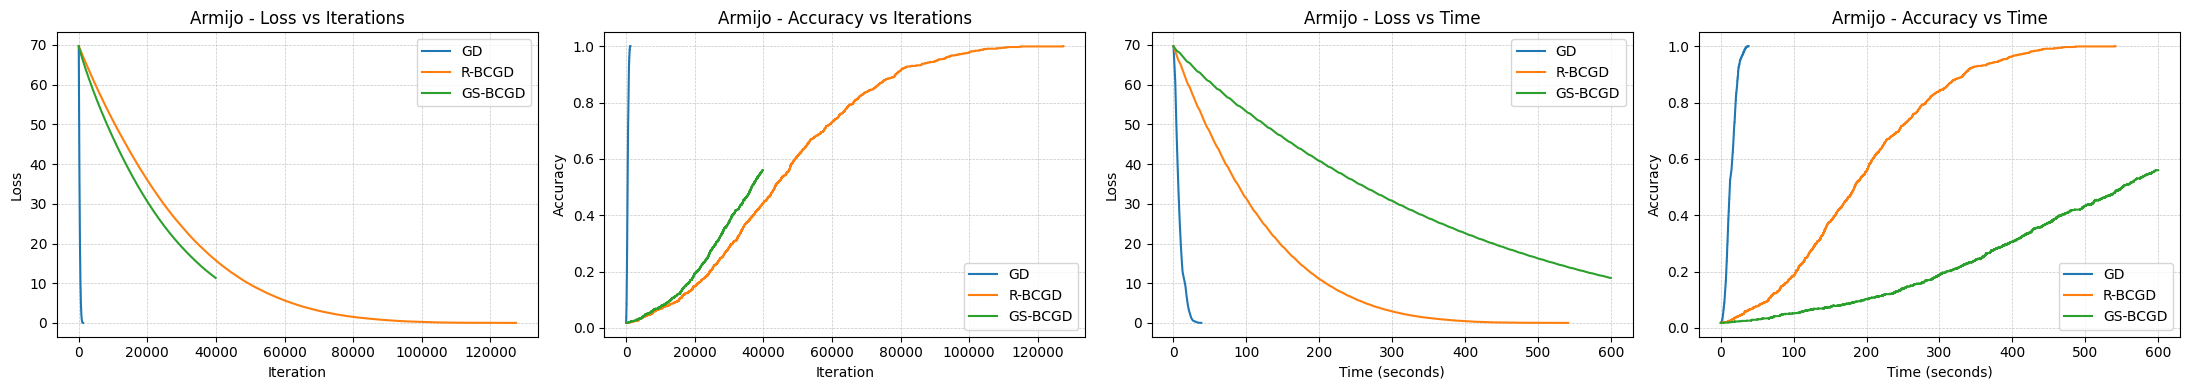

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 4))
ax1, ax2, ax3, ax4 = axes
for ax in axes:
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax1.plot(synthetic_gd_armijo["Loss History"], label="GD")
ax1.plot(synthetic_rbcgd_armijo["Loss History"], label="R-BCGD")
ax1.plot(synthetic_gs_armijo["Loss History"], label="GS-BCGD")
ax1.set_title("Armijo - Loss vs Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(synthetic_gd_armijo["Accuracy History"], label="GD")
ax2.plot(synthetic_rbcgd_armijo["Accuracy History"], label="R-BCGD")
ax2.plot(synthetic_gs_armijo["Accuracy History"], label="GS-BCGD")
ax2.set_title("Armijo - Accuracy vs Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Accuracy")
ax2.legend()

ax3.plot(synthetic_gd_armijo["Time"], synthetic_gd_armijo["Loss History"], label="GD")
ax3.plot(synthetic_rbcgd_armijo["Time"], synthetic_rbcgd_armijo["Loss History"], label="R-BCGD")
ax3.plot(synthetic_gs_armijo["Time"], synthetic_gs_armijo["Loss History"], label="GS-BCGD")
ax3.set_title("Armijo - Loss vs Time")
ax3.set_xlabel("Time (seconds)")
ax3.set_ylabel("Loss")
ax3.legend()


ax4.plot(synthetic_gd_armijo["Time"], synthetic_gd_armijo["Accuracy History"], label="GD")
ax4.plot(synthetic_rbcgd_armijo["Time"], synthetic_rbcgd_armijo["Accuracy History"], label="R-BCGD")
ax4.plot(synthetic_gs_armijo["Time"], synthetic_gs_armijo["Accuracy History"], label="GS-BCGD")
ax4.set_title("Armijo - Accuracy vs Time")
ax4.set_xlabel("Time (seconds)")
ax4.set_ylabel("Accuracy")
ax4.legend()

plt.tight_layout()
plt.show()

# REAL DATA (scaled)

In [ ]:
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import StandardScaler, MinMaxScaler

(data_train, y), (data_test, y_test) = mnist.load_data()
A = data_train.reshape(data_train.shape[0], -1)
# Scaled data (MinMaxScaler)
A = MinMaxScaler().fit_transform(A)
#A = StandardScaler().fit_transform(A)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
A.shape

(60000, 784)

## Execution real data

In [ ]:
d = A.shape[1]
k = int(np.max(y)) + 1
x_start = np.random.randn(d, k)
#x_start = np.zeros((d, k)) all weights start at 0
MAX_TIME = 600


loss_function, jacobian, probs_from_Z = generate_objective(A, y)

In [ ]:
real_gd_fixed = gradient_descent(
    loss_function,
    jacobian,
    a=A,
    y=y,
    x0=x_start,
    stepsize_strat='L',
    max_time=MAX_TIME
)

Lipschitz stepsize: 0.052505743245102564
The running time of the gradient descent with time as stop is 600.174001455307
1480


In [ ]:
real_gd_armijo = gradient_descent(
    loss_function,
    jacobian,
    a=A,
    y=y,
    x0=x_start,
    stepsize_strat='armijo',
    stepsize=1.0,
    max_time=MAX_TIME
)

The running time of the gradient descent with time as stop is 600.0368502140045
1060


In [ ]:


real_rbcgd_fixed = randomized_bcgd(
    loss_logits=loss_function,
    a_matrix=A,
    probs_from_Z=probs_from_Z,
    labels=y,
    x_matrix=x_start,
    armijo_flag=False,
    max_iter=1000000,
    max_time=MAX_TIME
)



Stopped because max_time=600 seconds was reached.


In [ ]:
real_rbcgd_armijo = randomized_bcgd(
    loss_logits=loss_function,
    a_matrix=A,
    probs_from_Z=probs_from_Z,
    labels=y,
    x_matrix=x_start,
    armijo_flag=True,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.


In [ ]:


real_gs_fixed = bcgd_GS(
    loss_logits=loss_function,
    a_matrix=A,
    labels=y,
    x_matrix=x_start,
    armijo_flag=False,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.


In [ ]:
real_gs_armijo = bcgd_GS(
    loss_logits=loss_function,
    a_matrix=A,
    labels=y,
    x_matrix=x_start,
    armijo_flag=True,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.


## Plot GD (real data)

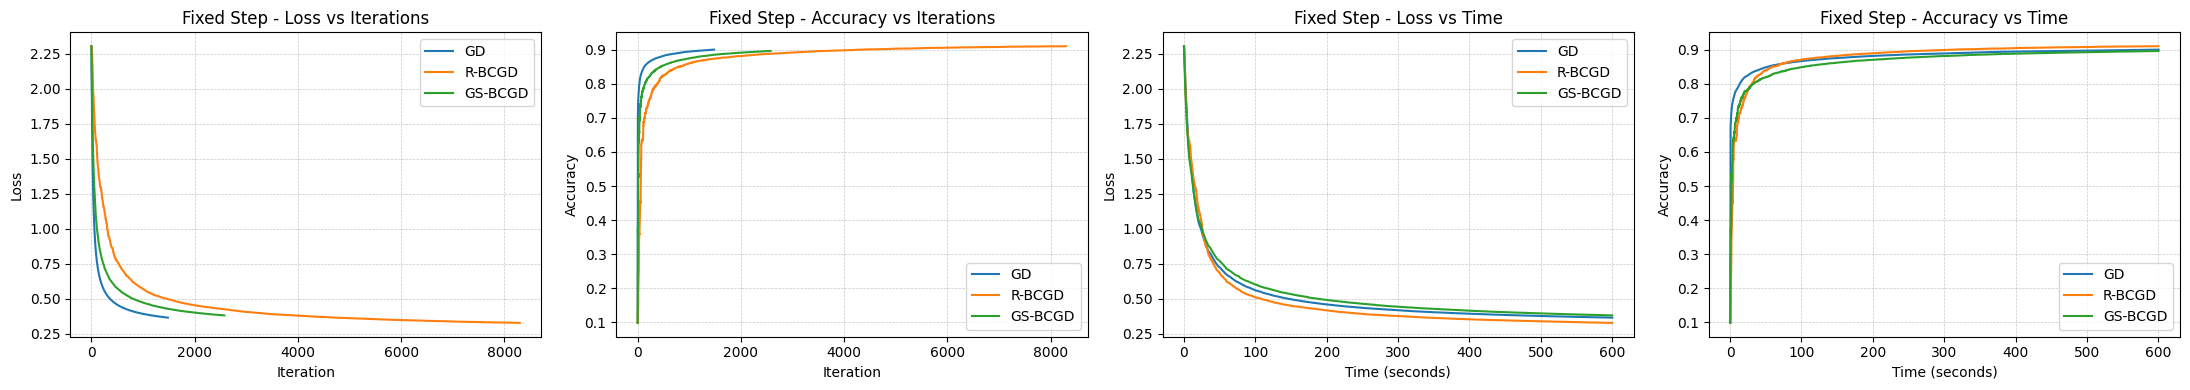

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 4))
ax1, ax2, ax3, ax4 = axes
for ax in axes:
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax1.plot(real_gd_fixed["Loss History"], label="GD")
ax1.plot(real_rbcgd_fixed["Loss History"], label="R-BCGD")
ax1.plot(real_gs_fixed["Loss History"], label="GS-BCGD")
ax1.set_title("Fixed Step - Loss vs Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(real_gd_fixed["Accuracy History"], label="GD")
ax2.plot(real_rbcgd_fixed["Accuracy History"], label="R-BCGD")
ax2.plot(real_gs_fixed["Accuracy History"], label="GS-BCGD")
ax2.set_title("Fixed Step - Accuracy vs Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Accuracy")
ax2.legend()

ax3.plot(real_gd_fixed["Time"], real_gd_fixed["Loss History"], label="GD")
ax3.plot(real_rbcgd_fixed["Time"], real_rbcgd_fixed["Loss History"], label="R-BCGD")
ax3.plot(real_gs_fixed["Time"], real_gs_fixed["Loss History"], label="GS-BCGD")
ax3.set_title("Fixed Step - Loss vs Time")
ax3.set_xlabel("Time (seconds)")
ax3.set_ylabel("Loss")
ax3.legend()

ax4.plot(real_gd_fixed["Time"], real_gd_fixed["Accuracy History"], label="GD")
ax4.plot(real_rbcgd_fixed["Time"], real_rbcgd_fixed["Accuracy History"], label="R-BCGD")
ax4.plot(real_gs_fixed["Time"], real_gs_fixed["Accuracy History"], label="GS-BCGD")
ax4.set_title("Fixed Step - Accuracy vs Time")
ax4.set_xlabel("Time (seconds)")
ax4.set_ylabel("Accuracy")
ax4.legend()

plt.tight_layout()
plt.show()

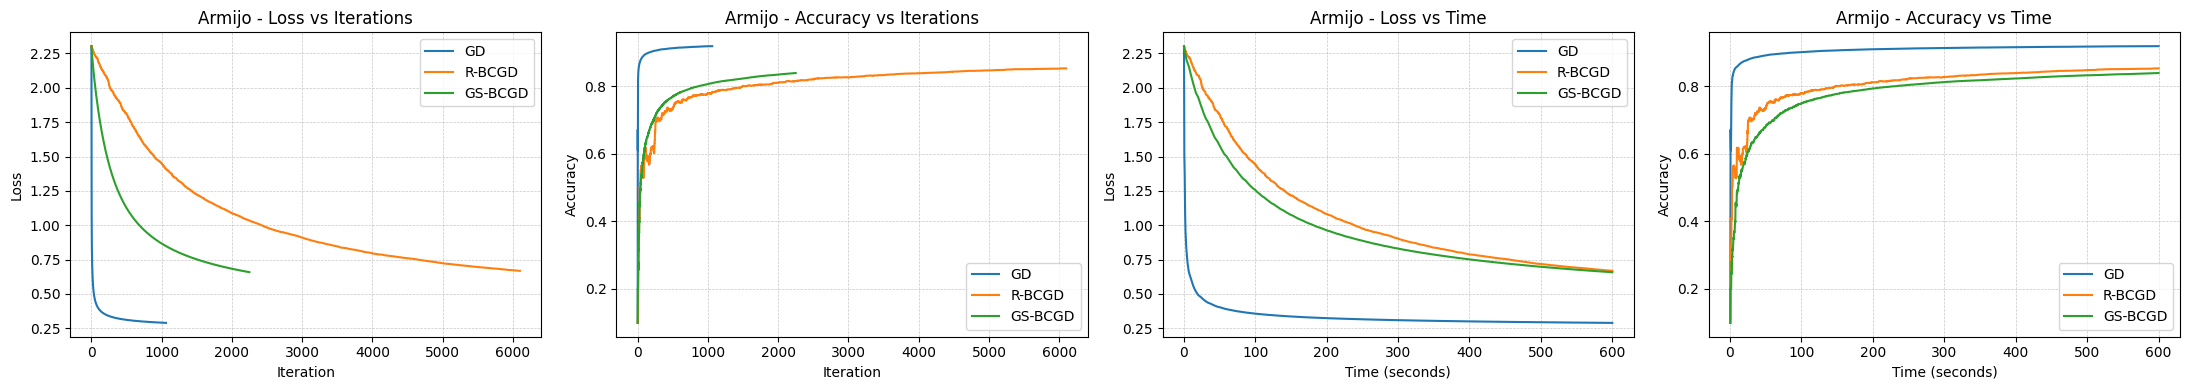

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 4))
ax1, ax2, ax3, ax4 = axes
for ax in axes:
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax1.plot(real_gd_armijo["Loss History"], label="GD")
ax1.plot(real_rbcgd_armijo["Loss History"], label="R-BCGD")
ax1.plot(real_gs_armijo["Loss History"], label="GS-BCGD")
ax1.set_title("Armijo - Loss vs Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(real_gd_armijo["Accuracy History"], label="GD")
ax2.plot(real_rbcgd_armijo["Accuracy History"], label="R-BCGD")
ax2.plot(real_gs_armijo["Accuracy History"], label="GS-BCGD")
ax2.set_title("Armijo - Accuracy vs Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Accuracy")
ax2.legend()

ax3.plot(real_gd_armijo["Time"], real_gd_armijo["Loss History"], label="GD")
ax3.plot(real_rbcgd_armijo["Time"], real_rbcgd_armijo["Loss History"], label="R-BCGD")
ax3.plot(real_gs_armijo["Time"], real_gs_armijo["Loss History"], label="GS-BCGD")
ax3.set_title("Armijo - Loss vs Time")
ax3.set_xlabel("Time (seconds)")
ax3.set_ylabel("Loss")
ax3.legend()

ax4.plot(real_gd_armijo["Time"], real_gd_armijo["Accuracy History"], label="GD")
ax4.plot(real_rbcgd_armijo["Time"], real_rbcgd_armijo["Accuracy History"], label="R-BCGD")
ax4.plot(real_gs_armijo["Time"], real_gs_armijo["Accuracy History"], label="GS-BCGD")
ax4.set_title("Armijo - Accuracy vs Time")
ax4.set_xlabel("Time (seconds)")
ax4.set_ylabel("Accuracy")
ax4.legend()

plt.tight_layout()
plt.show()

# REAL DATA (raw)

In [ ]:
from tensorflow.keras.datasets import mnist

(data_train, y), (data_test, y_test) = mnist.load_data()

A = data_train.reshape(data_train.shape[0], -1)

In [ ]:
A = data_train.reshape(data_train.shape[0], -1)

In [ ]:
import pandas as pd

In [ ]:
pd.DataFrame(A).describe()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [ ]:
d = A.shape[1]
k = int(np.max(y)) + 1
x_start = np.random.randn(d, k)
#x_start = np.zeros((d, k)) all weights start at 0
MAX_TIME = 600


loss_function, jacobian, probs_from_Z = generate_objective(A, y)

## Execution raw data

In [ ]:
real_gd_fixed_raw = gradient_descent(
    loss_function,
    jacobian,
    a=A,
    y=y,
    x0=x_start,
    stepsize_strat='L',
    max_time=MAX_TIME
)

Lipschitz stepsize: 8.074701068826154e-07
The running time of the gradient descent with time as stop is 600.3764884471893
1268


In [ ]:
real_gd_armijo_raw = gradient_descent(
    loss_function,
    jacobian,
    a=A,
    y=y,
    x0=x_start,
    stepsize_strat='armijo',
    stepsize=1.0,
    max_time=MAX_TIME
)

The running time of the gradient descent with time as stop is 600.3733875751495
826


In [ ]:
real_rbcgd_fixed_raw = randomized_bcgd(
    loss_logits=loss_function,
    a_matrix=A,
    probs_from_Z=probs_from_Z,
    labels=y,
    x_matrix=x_start,
    armijo_flag=False,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.


In [ ]:
real_rbcgd_armijo_raw = randomized_bcgd(
    loss_logits=loss_function,
    a_matrix=A,
    probs_from_Z=probs_from_Z,
    labels=y,
    x_matrix=x_start,
    armijo_flag=True,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.


In [ ]:
real_gs_fixed_raw = bcgd_GS(
    loss_logits=loss_function,
    a_matrix=A,
    labels=y,
    x_matrix=x_start,
    armijo_flag=False,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.


In [ ]:
real_gs_armijo_raw = bcgd_GS(
    loss_logits=loss_function,
    a_matrix=A,
    labels=y,
    x_matrix=x_start,
    armijo_flag=True,
    max_iter=1000000,
    max_time=MAX_TIME
)

Stopped because max_time=600 seconds was reached.


## Plot (raw data)

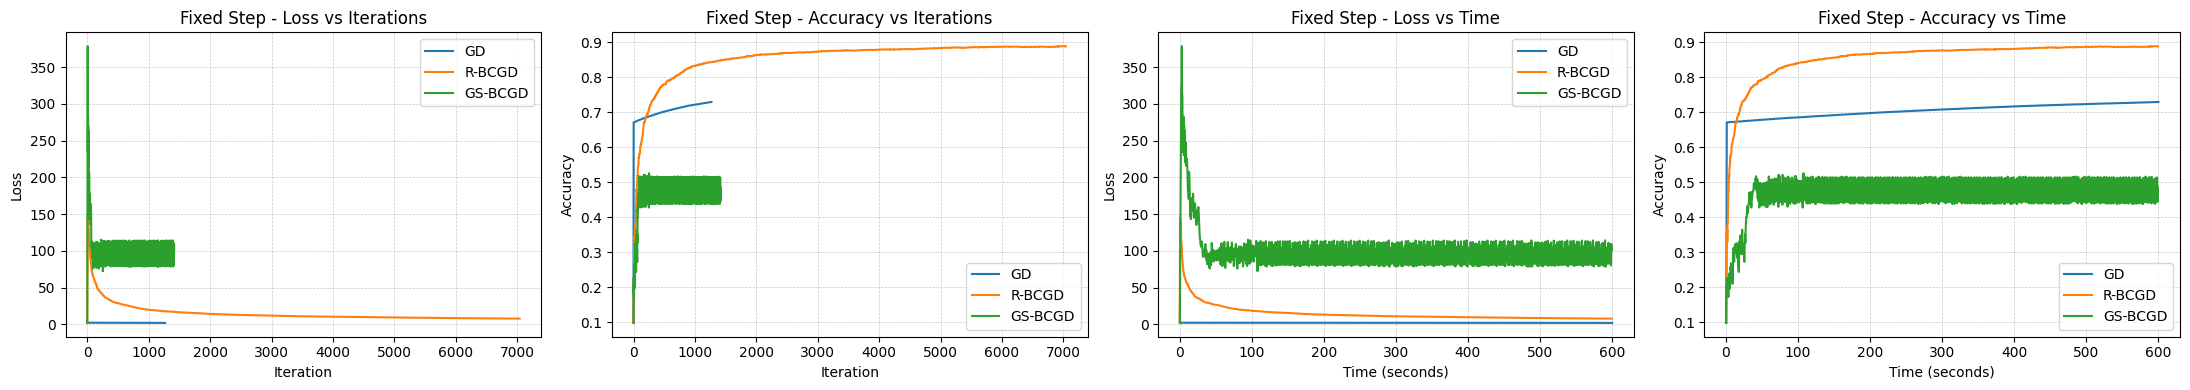

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 4))
ax1, ax2, ax3, ax4 = axes
for ax in axes:
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax1.plot(real_gd_fixed_raw["Loss History"], label="GD")
ax1.plot(real_rbcgd_fixed_raw["Loss History"], label="R-BCGD")
ax1.plot(real_gs_fixed_raw["Loss History"], label="GS-BCGD")
ax1.set_title("Fixed Step - Loss vs Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(real_gd_fixed_raw["Accuracy History"], label="GD")
ax2.plot(real_rbcgd_fixed_raw["Accuracy History"], label="R-BCGD")
ax2.plot(real_gs_fixed_raw["Accuracy History"], label="GS-BCGD")
ax2.set_title("Fixed Step - Accuracy vs Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Accuracy")
ax2.legend()

ax3.plot(real_gd_fixed_raw["Time"], real_gd_fixed_raw["Loss History"], label="GD")
ax3.plot(real_rbcgd_fixed_raw["Time"], real_rbcgd_fixed_raw["Loss History"], label="R-BCGD")
ax3.plot(real_gs_fixed_raw["Time"], real_gs_fixed_raw["Loss History"], label="GS-BCGD")
ax3.set_title("Fixed Step - Loss vs Time")
ax3.set_xlabel("Time (seconds)")
ax3.set_ylabel("Loss")
ax3.legend()

ax4.plot(real_gd_fixed_raw["Time"], real_gd_fixed_raw["Accuracy History"], label="GD")
ax4.plot(real_rbcgd_fixed_raw["Time"], real_rbcgd_fixed_raw["Accuracy History"], label="R-BCGD")
ax4.plot(real_gs_fixed_raw["Time"], real_gs_fixed_raw["Accuracy History"], label="GS-BCGD")
ax4.set_title("Fixed Step - Accuracy vs Time")
ax4.set_xlabel("Time (seconds)")
ax4.set_ylabel("Accuracy")
ax4.legend()

plt.tight_layout()
plt.show()

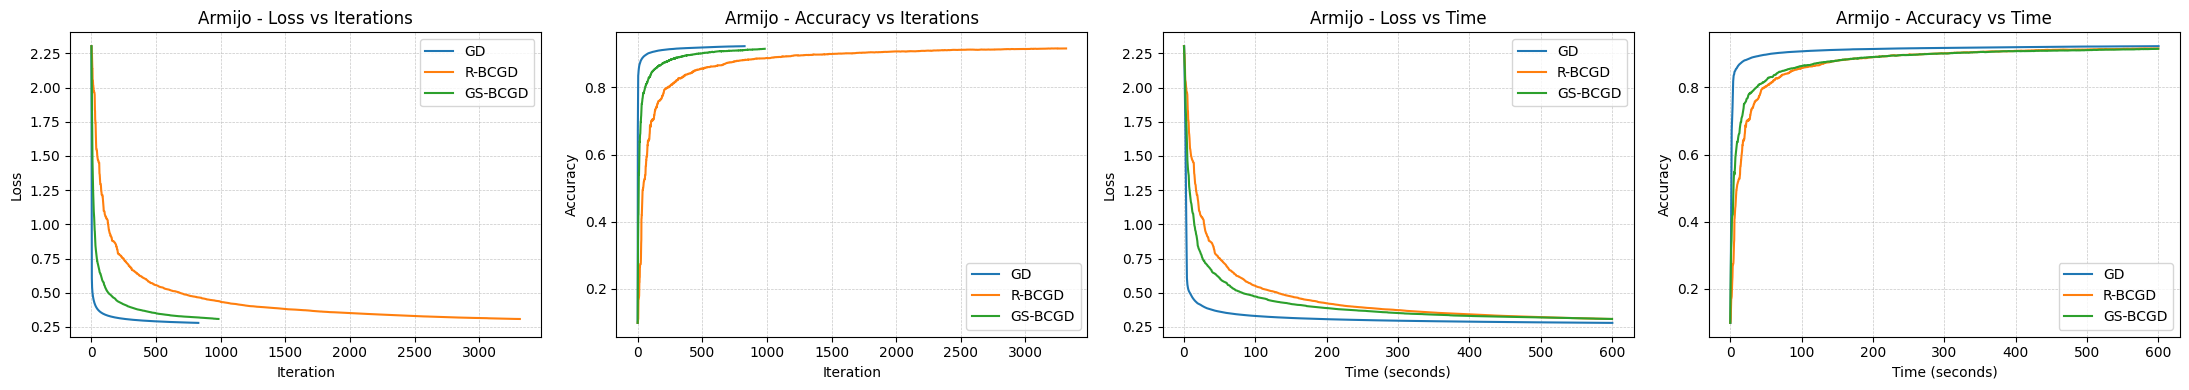

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 4))
ax1, ax2, ax3, ax4 = axes
for ax in axes:
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


ax1.plot(real_gd_armijo_raw["Loss History"], label="GD")
ax1.plot(real_rbcgd_armijo_raw["Loss History"], label="R-BCGD")
ax1.plot(real_gs_armijo_raw["Loss History"], label="GS-BCGD")
ax1.set_title("Armijo - Loss vs Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(real_gd_armijo_raw["Accuracy History"], label="GD")
ax2.plot(real_rbcgd_armijo_raw["Accuracy History"], label="R-BCGD")
ax2.plot(real_gs_armijo_raw["Accuracy History"], label="GS-BCGD")
ax2.set_title("Armijo - Accuracy vs Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Accuracy")
ax2.legend()

ax3.plot(real_gd_armijo_raw["Time"], real_gd_armijo_raw["Loss History"], label="GD")
ax3.plot(real_rbcgd_armijo_raw["Time"], real_rbcgd_armijo_raw["Loss History"], label="R-BCGD")
ax3.plot(real_gs_armijo_raw["Time"], real_gs_armijo_raw["Loss History"], label="GS-BCGD")
ax3.set_title("Armijo - Loss vs Time")
ax3.set_xlabel("Time (seconds)")
ax3.set_ylabel("Loss")
ax3.legend()

ax4.plot(real_gd_armijo_raw["Time"], real_gd_armijo_raw["Accuracy History"], label="GD")
ax4.plot(real_rbcgd_armijo_raw["Time"], real_rbcgd_armijo_raw["Accuracy History"], label="R-BCGD")
ax4.plot(real_gs_armijo_raw["Time"], real_gs_armijo_raw["Accuracy History"], label="GS-BCGD")
ax4.set_title("Armijo - Accuracy vs Time")
ax4.set_xlabel("Time (seconds)")
ax4.set_ylabel("Accuracy")
ax4.legend()

plt.tight_layout()
plt.show()